In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


Matplotlib is building the font cache; this may take a moment.


In [6]:
# 1. Load data
df = pd.read_csv("marketing_campaign.csv",sep="\t")


In [7]:
# 2. Quick info before cleaning
print("Shape before cleaning:", df.shape)
print(df.isna().sum())

Shape before cleaning: (2240, 29)
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [8]:
# 3. Drop duplicate rows (if any)
df = df.drop_duplicates()

In [9]:
# 4. Handle missing values
df = df.dropna(subset=["Income"])  # or use median instead
# df["Income"] = df["Income"].fillna(df["Income"].median())

In [10]:
# 5. Convert data types
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y", errors="coerce")

numeric_cols = [
    "Year_Birth", "Income", "Kidhome", "Teenhome", "Recency",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds", "NumDealsPurchases",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth", "AcceptedCmp1", "AcceptedCmp2",
    "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Complain",
    "Z_CostContact", "Z_Revenue", "Response"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols] = df[numeric_cols].fillna(0)

In [11]:
# Feature engineering
current_year = 2026
df["Age"] = current_year - df["Year_Birth"]
df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]

spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds"
]
df["TotalSpent"] = df[spend_cols].sum(axis=1)

In [12]:
# Remove simple outliers
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]
df = df[df["Income"] > 0]

df = df.reset_index(drop=True)

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (2213, 32)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalChildren,TotalSpent
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,3,11,1,69,0,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,3,11,0,72,2,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,3,11,0,61,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,3,11,0,42,1,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,3,11,0,45,1,422


In [13]:
print("Shape before cleaning:", df.shape)
print(df.isna().sum())

Shape before cleaning: (2213, 32)
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
Age                    0
TotalChildren          0
TotalSpent             0
dtype: int64


In [ ]:

%matplotlib inline
sns.set(style="whitegrid")

# Load data (tab-separated)
df = pd.read_csv("marketing_campaign.csv", sep="\t")

# Basic cleaning / feature engineering (short version)
df = df.dropna(subset=["Income"])  # drop rows with missing income
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y", errors="coerce")

numeric_cols = [
    "Year_Birth", "Income", "Kidhome", "Teenhome", "Recency",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds", "NumDealsPurchases",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth", "AcceptedCmp1", "AcceptedCmp2",
    "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Complain",
    "Z_CostContact", "Z_Revenue", "Response"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols] = df[numeric_cols].fillna(0)

current_year = 2026
df["Age"] = current_year - df["Year_Birth"]

spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds"
]
df["TotalSpent"] = df[spend_cols].sum(axis=1)

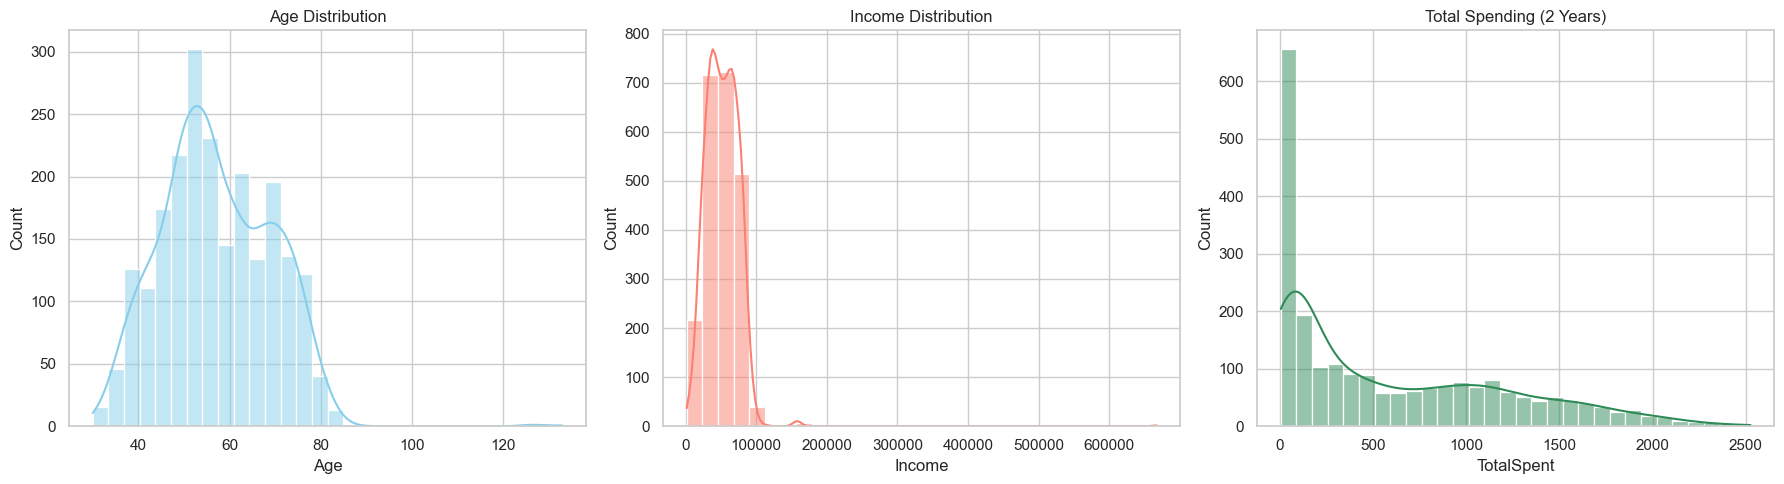

In [15]:
# Histograms: Age, Income, TotalSpent
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["Age"], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Age Distribution")

sns.histplot(df["Income"], bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Income Distribution")

sns.histplot(df["TotalSpent"], bins=30, kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Total Spending (2 Years)")

plt.tight_layout()
plt.show()

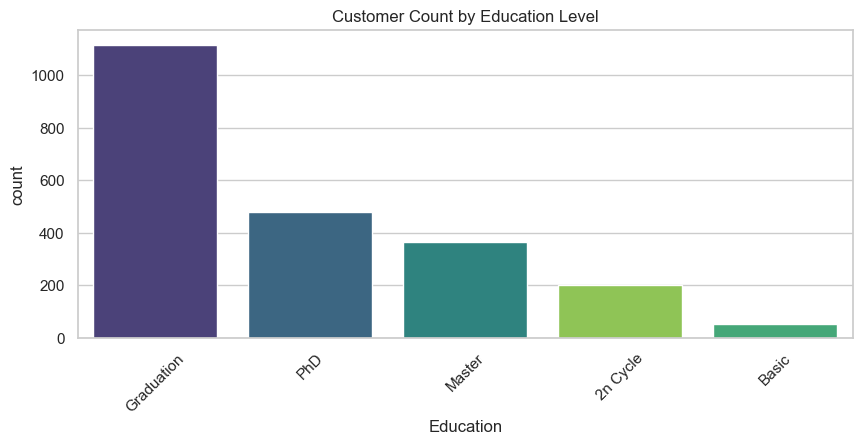

In [20]:
# Bar plots: Education and Marital Status
plt.figure(figsize=(10,4))
sns.countplot(
    data=df,
    x="Education",
    hue="Education",
    order=df["Education"].value_counts().index,
    palette="viridis",
    legend=False
)
plt.xticks(rotation=45)
plt.title("Customer Count by Education Level")
plt.show()

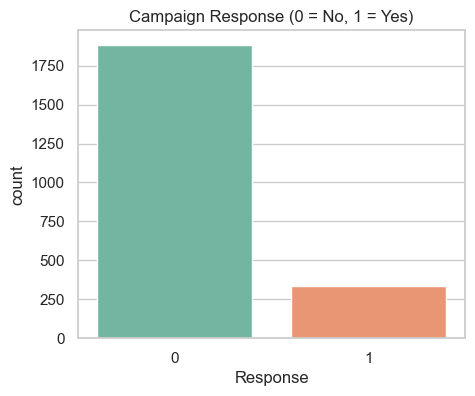

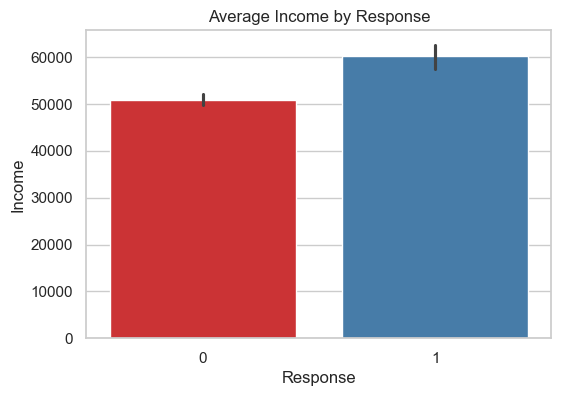

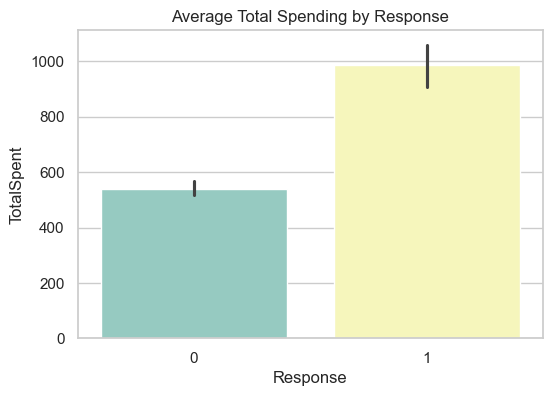

In [21]:
#Response vs. other variables
# Response vs. other variables

# 1) Response count
plt.figure(figsize=(5,4))
sns.countplot(
    data=df,
    x="Response",
    hue="Response",
    palette="Set2",
    legend=False
)
plt.title("Campaign Response (0 = No, 1 = Yes)")
plt.show()

# 2) Average income by response
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="Response",
    y="Income",
    hue="Response",
    estimator=np.mean,
    palette="Set1",
    legend=False
)
plt.title("Average Income by Response")
plt.show()

# 3) Average total spent by response
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="Response",
    y="TotalSpent",
    hue="Response",
    estimator=np.mean,
    palette="Set3",
    legend=False
)
plt.title("Average Total Spending by Response")
plt.show()

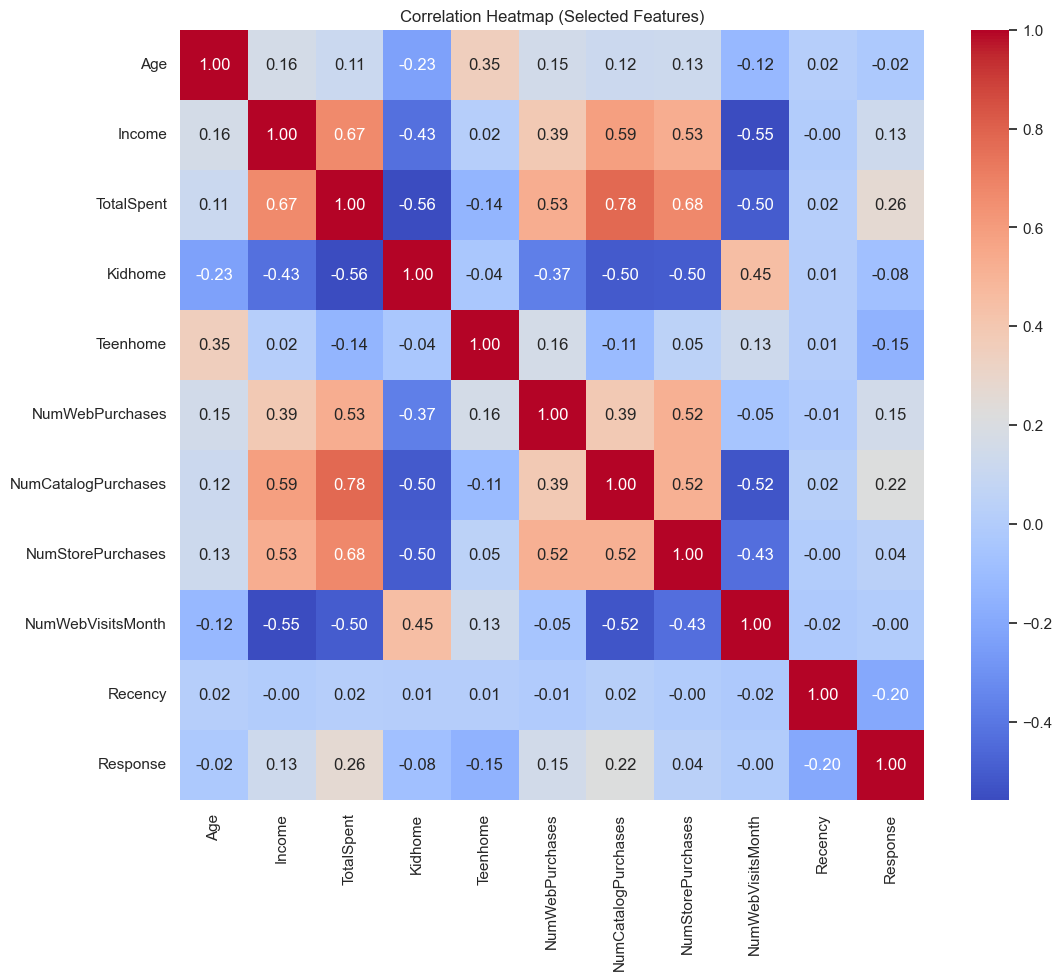

In [19]:
#Correlation heaplt.figure(figsize=(12,10))
plt.figure(figsize=(12,10))
corr = df[["Age", "Income", "TotalSpent", "Kidhome", "Teenhome",
           "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
           "NumWebVisitsMonth", "Recency", "Response"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Selected Features)")
plt.show()


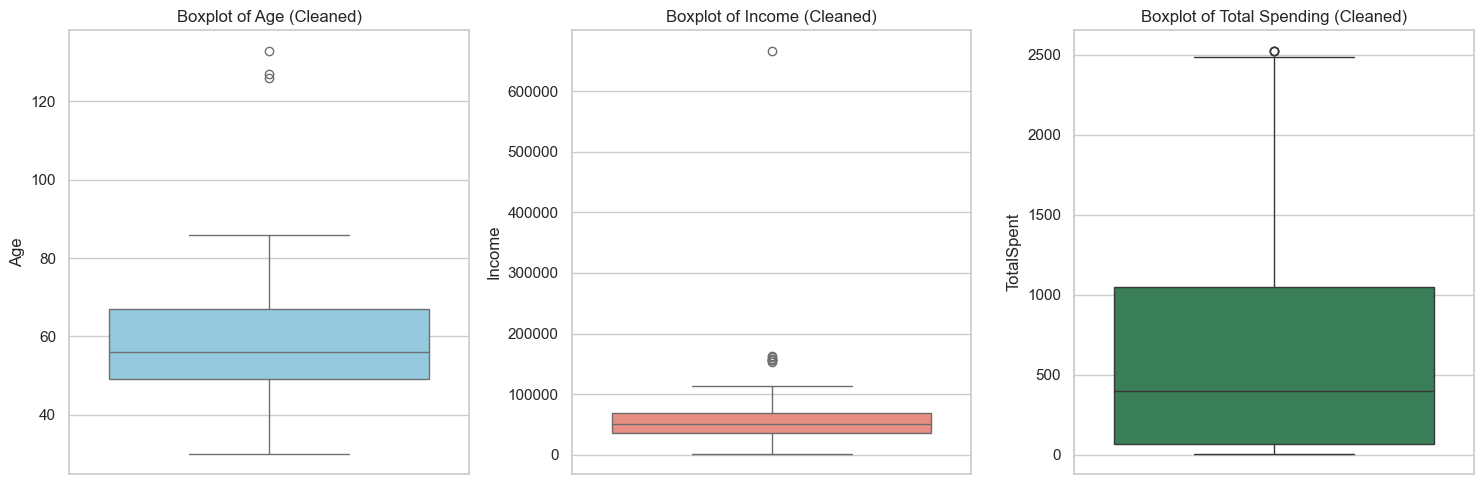

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Boxplots for key numeric variables after cleaning
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df["Age"], color="skyblue")
plt.title("Boxplot of Age (Cleaned)")

plt.subplot(1, 3, 2)
sns.boxplot(y=df["Income"], color="salmon")
plt.title("Boxplot of Income (Cleaned)")

plt.subplot(1, 3, 3)
sns.boxplot(y=df["TotalSpent"], color="seagreen")
plt.title("Boxplot of Total Spending (Cleaned)")

plt.tight_layout()
plt.show()

In [26]:
def remove_outliers_iqr(data, cols):
    df_clean = data.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        print(f"{col}: kept {df_clean.shape[0]} rows after removing outliers")

    return df_clean

cols_to_check = ["Age", "Income", "TotalSpent"]
df_no_outliers = remove_outliers_iqr(df, cols_to_check)

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)


Age: kept 2213 rows after removing outliers
Income: kept 2205 rows after removing outliers
TotalSpent: kept 2202 rows after removing outliers
Original shape: (2216, 31)
After removing outliers: (2202, 31)


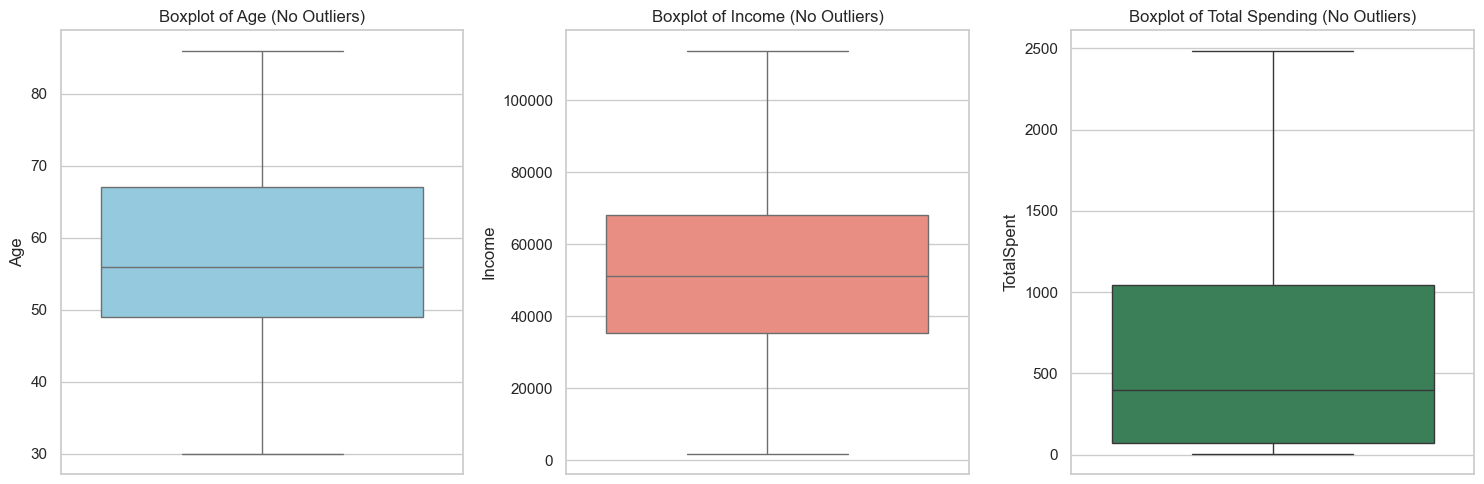

In [25]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_no_outliers["Age"], color="skyblue")
plt.title("Boxplot of Age (No Outliers)")

plt.subplot(1, 3, 2)
sns.boxplot(y=df_no_outliers["Income"], color="salmon")
plt.title("Boxplot of Income (No Outliers)")

plt.subplot(1, 3, 3)
sns.boxplot(y=df_no_outliers["TotalSpent"], color="seagreen")
plt.title("Boxplot of Total Spending (No Outliers)")

plt.tight_layout()
plt.show()

Response value counts:
Response
0    1880
1     333
Name: count, dtype: int64

Percentages:
Response
0    84.95
1    15.05
Name: proportion, dtype: float64


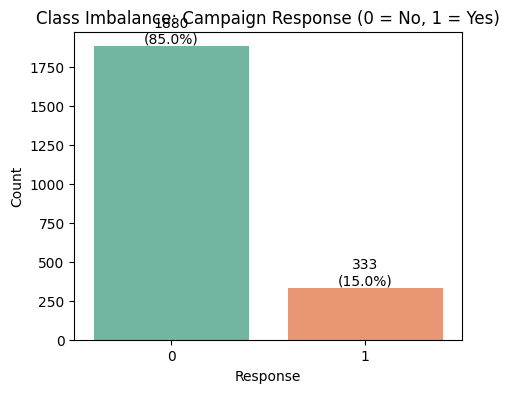

In [11]:
#Check and visualize class imbalance
# Count of each class
print("Response value counts:")
print(df["Response"].value_counts())
print("\nPercentages:")
print(df["Response"].value_counts(normalize=True).mul(100).round(2))

# Bar plot
plt.figure(figsize=(5, 4))
sns.countplot(
    data=df,
    x="Response",
    hue="Response",
    palette="Set2",
    legend=False
)
plt.title("Class Imbalance: Campaign Response (0 = No, 1 = Yes)")
plt.xlabel("Response")
plt.ylabel("Count")
for i, (count, pct) in enumerate(zip(
    df["Response"].value_counts().values,
    df["Response"].value_counts(normalize=True).mul(100).values
)):
    plt.text(i, count + 20, f"{count}\n({pct:.1f}%)", ha="center")
plt.show()

In [12]:
from imblearn.over_sampling import SMOTE

# Target ratio: minority (Yes) = 30% of total → ratio No:Yes ≈ 70:30
# sampling_strategy = 0.43 means Yes count = 0.43 * No count → ~30% Yes
smote = SMOTE(sampling_strategy=0.43, random_state=42)  # 0.43 ≈ 30/(100-30)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE (aim ~70% No, ~30% Yes):")
print(y_train_bal.value_counts(normalize=True).mul(100).round(2))

After SMOTE (aim ~70% No, ~30% Yes):
Response
0    69.95
1    30.05
Name: proportion, dtype: float64


Response value counts (after balancing):
Response
0    1504
1     646
Name: count, dtype: int64

Percentages (after balancing):
Response
0    69.95
1    30.05
Name: proportion, dtype: float64


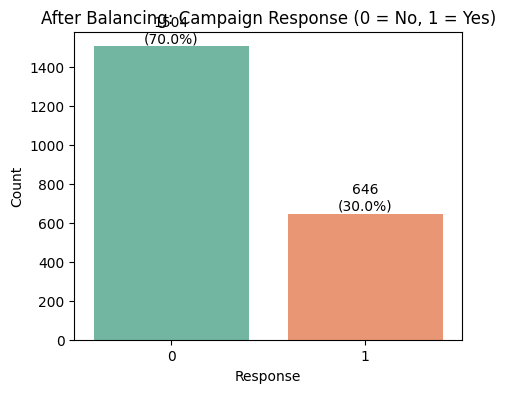

In [15]:
# Check and visualize class balance AFTER balancing (e.g. after SMOTE)

# Count of each class (use your balanced target variable)
y_bal = y_train_bal  # or whatever you named it after SMOTE fit_resample

print("Response value counts (after balancing):")
print(pd.Series(y_bal).value_counts())
print("\nPercentages (after balancing):")
print(pd.Series(y_bal).value_counts(normalize=True).mul(100).round(2))

# Bar plot for balanced data
df_bal_plot = pd.DataFrame({"Response": y_bal})

plt.figure(figsize=(5, 4))
sns.countplot(
    data=df_bal_plot,
    x="Response",
    hue="Response",
    palette="Set2",
    legend=False
)
plt.title("After Balancing: Campaign Response (0 = No, 1 = Yes)")
plt.xlabel("Response")
plt.ylabel("Count")

counts = pd.Series(y_bal).value_counts().values
pcts = pd.Series(y_bal).value_counts(normalize=True).mul(100).values
for i, (count, pct) in enumerate(zip(counts, pcts)):
    plt.text(i, count + 20, f"{count}\n({pct:.1f}%)", ha="center")

plt.show()

In [16]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# --- Handle class imbalance: aim for good balance (~70% No, ~30% Yes) ---

# Before balancing
print("Before balancing (train set):")
print(pd.Series(y_train).value_counts())
print(pd.Series(y_train).value_counts(normalize=True).mul(100).round(2))

# SMOTE: sampling_strategy=0.43 → minority (Yes) ≈ 30% of total (70% No, 30% Yes)
# For 50-50 use sampling_strategy=1
smote = SMOTE(sampling_strategy=0.43, random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# After balancing
print("\nAfter balancing (train set):")
print(pd.Series(y_train_balanced).value_counts())
print(pd.Series(y_train_balanced).value_counts(normalize=True).mul(100).round(2))

# Use these for training (test set stays unchanged)
# X_train_balanced, y_train_balanced  →  for model.fit()
# X_test_scaled, y_test               →  for model evaluation

Before balancing (train set):
Response
0    1504
1     266
Name: count, dtype: int64
Response
0    84.97
1    15.03
Name: proportion, dtype: float64

After balancing (train set):
Response
0    1504
1     646
Name: count, dtype: int64
Response
0    69.95
1    30.05
Name: proportion, dtype: float64


In [20]:
# Data preprocessing + scaling (single block)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

target = "Response"
df_ml = df.copy()

# Encode categoricals so all features are numeric
le_edu = LabelEncoder()
le_marital = LabelEncoder()
df_ml["Education"] = le_edu.fit_transform(df_ml["Education"].astype(str))
df_ml["Marital_Status"] = le_marital.fit_transform(df_ml["Marital_Status"].astype(str))

# Features and target
exclude = ["ID", "Dt_Customer", target]
feature_cols = [c for c in df_ml.columns if c not in exclude]
X = df_ml[feature_cols]
y = df_ml[target]

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

# Summary (one place)
print("Project: Analysing Customers Personality for Business Improvement using ML")
print("Preprocessing: LabelEncoder (Education, Marital_Status) + StandardScaler")
print("Features:", feature_cols)
print("Train size:", X_train_scaled.shape[0], "| Test size:", X_test_scaled.shape[0])
print("Target (train):", pd.Series(y_train).value_counts().to_dict())
print("Scaled train - mean (first 5):", X_train_scaled.iloc[:, :5].mean().round(4).to_dict())
print("Scaled train - std  (first 5):", X_train_scaled.iloc[:, :5].std().round(4).to_dict())

Project: Analysing Customers Personality for Business Improvement using ML
Preprocessing: LabelEncoder (Education, Marital_Status) + StandardScaler
Features: ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Age', 'TotalSpent']
Train size: 1770 | Test size: 443
Target (train): {0: 1504, 1: 266}
Scaled train - mean (first 5): {'Year_Birth': -0.0, 'Education': 0.0, 'Marital_Status': 0.0, 'Income': -0.0, 'Kidhome': 0.0}
Scaled train - std  (first 5): {'Year_Birth': 1.0003, 'Education': 1.0003, 'Marital_Status': 1.0003, 'Income': 1.0003, 'Kidhome': 1.0003}


In [28]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 518.7 kB/s eta 0:03:16
   ---------------------------------------- 0.8/101.7 MB 686.2 kB/s eta 0:02:28
   ---------------------------------------- 1.0/101.7 MB 756.8 kB/s eta 0:02:13
   ---------------------------------------- 1.0/101.7 MB 756.8 kB/s eta 0:02:13
    --------------------------------------- 1.3/101.7 MB 723.6 kB/s eta 0:02:19
    --------------------------------------- 1.3/101.7 MB 723.6 kB/s eta 0:02:19
    --------------------------------------- 1.6/101.7 MB 751.9 kB/s eta 0:02:14
    --------------------------------------- 1.8/101.7 MB 759.0 kB/s eta 0:02:12
    --------------------------------------- 2.1/101.7 MB 788.7 kB/s eta 0:0

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost classifier
xgb_model = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss"
)
xgb_model.fit(X_tr, y_tr)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print("=" * 60)
print("XGBOOST")
print("=" * 60)
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, target_names=["No", "Yes"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

C:\Users\satee\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:13:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBOOST
Accuracy: 0.8736

Classification Report:
               precision    recall  f1-score   support

          No       0.89      0.97      0.93       376
         Yes       0.66      0.34      0.45        67

    accuracy                           0.87       443
   macro avg       0.77      0.66      0.69       443
weighted avg       0.86      0.87      0.86       443

Confusion Matrix:
 [[364  12]
 [ 44  23]]


In [30]:
import pandas as pd

# If you still have y_pred_lr and y_pred_dt from earlier
print(pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "XGBoost"],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_dt), 4),
        round(accuracy_score(y_test, y_pred_xgb), 4)
    ]
}))

                 Model  Accuracy
0  Logistic Regression    0.8668
1        Decision Tree    0.8330
2              XGBoost    0.8736


In [ ]:
# ===================== FULL PIPELINE WITH TUNED XGBOOST =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
import xgboost as xgb


# 2) Encode categoricals & build X, y
target = "Response"
df_ml = df.copy()
df_ml["Education"] = LabelEncoder().fit_transform(df_ml["Education"].astype(str))
df_ml["Marital_Status"] = LabelEncoder().fit_transform(df_ml["Marital_Status"].astype(str))

exclude = ["ID", "Dt_Customer", target]
feature_cols = [c for c in df_ml.columns if c not in exclude]
X = df_ml[feature_cols]
y = df_ml[target]

# 3) Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5) SMOTE (better class balance ~70/30)
smote = SMOTE(sampling_strategy=0.43, random_state=42, k_neighbors=5)
X_tr, y_tr = smote.fit_resample(X_train_scaled, y_train)

print("Train size after SMOTE:", X_tr.shape[0], "| Test size:", X_test_scaled.shape[0])
print("Train class distribution:", pd.Series(y_tr).value_counts(normalize=True).mul(100).round(2).to_dict())

# 6) Base XGBoost + hyperparameter tuning
xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    nthread=-1
)

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2]
}

rand_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,          # increase for more search (slower)
    scoring="accuracy",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rand_search.fit(X_tr, y_tr)

print("\nBest CV accuracy:", rand_search.best_score_)
print("Best params:", rand_search.best_params_)

# 7) Evaluate best model on test set
best_xgb = rand_search.best_estimator_
y_pred_xgb_best = best_xgb.predict(X_test_scaled)

print("\n" + "="*60)
print("TUNED XGBOOST (best model)")
print("="*60)
test_acc = accuracy_score(y_test, y_pred_xgb_best)
print("Test Accuracy:", round(test_acc, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_best, target_names=["No", "Yes"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_best))